In [1]:
# %matplotlib inline
%time from hikyuu.interactive import *
#use_draw_engine('echarts') #use_draw_engine('matplotlib')  #the default is 'matplotlib' drawing

Initialize hikyuu_2.8.2_202609250345_RELEASE_macosx_arm64 ...
2026-09-25 13:32:44.721 [HKU-I] - current python version: 3.13.12 (main.cpp:77)


2026-09-25 13:32:46,129 [INFO] runing in interactive session [<module>] (/Users/fasiondog/workspace/hikyuu/hikyuu/__init__.py:149) [hikyuu::hku_info]
2026-09-25 13:32:46,129 [INFO] running in jupyter [<module>] (/Users/fasiondog/workspace/hikyuu/hikyuu/__init__.py:156) [hikyuu::hku_info]


2026-09-25 13:32:46.133 [HKU-I] - 插件路径: /Users/fasiondog/workspace/hku_plugin/hikyuu_plugin (StockManager.cpp:124)
2026-09-25 13:32:46.162 [HKU-I] - Using CLICKHOUSE BaseInfoDriver (BaseInfoDriver.cpp:56)
2026-09-25 13:32:46.186 [HKU-I] - 加载市场信息…… (StockManager.cpp:1050)
2026-09-25 13:32:46.201 [HKU-I] - 加载证券类型信息…… (StockManager.cpp:1067)
2026-09-25 13:32:46.220 [HKU-I] - 加载证券信息…… (StockManager.cpp:948)
2026-09-25 13:32:46.357 [HKU-I] - 加载权息数据…… (StockManager.cpp:1170)
2026-09-25 13:32:46.612 [HKU-I] - 加载板块信息…… (StockManager.cpp:214)
2026-09-25 13:32:46.764 [HKU-I] - 加载K线数据…… (StockManager.cpp:221)
2026-09-25 13:32:46.764 [HKU-I] - 预加载 day K线数据至缓存 (最大数量: 100000)! (StockManager.cpp:395)
2026-09-25 13:32:46.764 [HKU-I] - 0.59 秒数据加载完毕. (StockManager.cpp:231)
CPU times: user 2.33 s, sys: 190 ms, total: 2.52 s
Wall time: 3.26 s


1. A simple example
========

Query and plot the K-line data of the Shanghai Composite Index over the last 100 trading days

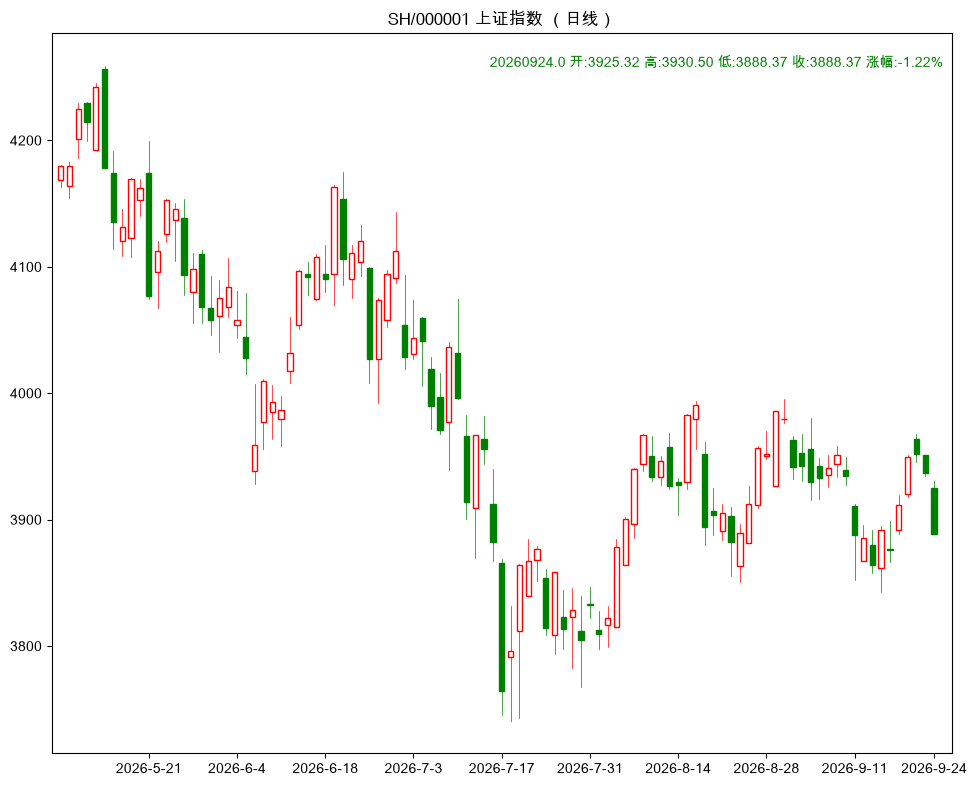

In [2]:
s = sm['sh000001']
k = s.get_kdata(Query(-100))  
k.plot()

2. View and traverse the K-line data
==========

The K-line data can be traversed and viewed like a list

In [3]:
s = sm['sh000001']
k = s.get_kdata(Query(-100))  
print(k)

KData{
  size : 100
  stock: Stock(SH, 000001, 上证指数, 指数, 1, 1990-12-20 00:00:00, +infinity),
  query: KQuery(-100, 9223372036854775807, INDEX, DAY, NO_RECOVER)
  first: KRecord(Datetime(20260507000000), 4168.4500, 4180.2090, 4163.1400, 4180.0890, 135909946.1632, 6855741.9520)
  last: KRecord(Datetime(20260924000000), 3925.3200, 3930.5000, 3888.3700, 3888.3700, 78361296.8960, 4385304.0000)
}


In [4]:
# View the K-line values of the last 5 trading days
k[-5:]

KRecordList[KRecord(Datetime(20260918000000), 3891.9600, 3919.6700, 3888.5000, 3911.8700, 99416945.4592, 4857125.0000), KRecord(Datetime(20260921000000), 3920.2700, 3950.9400, 3918.1300, 3949.9100, 94681910.4768, 5023549.0000), KRecord(Datetime(20260922000000), 3963.8100, 3967.6800, 3945.4200, 3952.1300, 100799558.4512, 5061484.0000), KRecord(Datetime(20260923000000), 3951.3700, 3951.5200, 3934.4600, 3936.5200, 83413283.6352, 4669139.0000), KRecord(Datetime(20260924000000), 3925.3200, 3930.5000, 3888.3700, 3888.3700, 78361296.8960, 4385304.0000)]

In [5]:
# Traverse to find the maximum close price
max_close = 0
for v in k:
    if v.close > max_close:
        max_close = v.close
print(max_close)

4242.569


The K-line data (KData) is actually an array composed of KRecords. The attributes of KRecord are as follows:

In [6]:
print("Date - ", k[0].datetime)
print("Open - ", k[0].open)
print("High - ", k[0].high)
print("Low - ", k[0].low)
print("Close - ", k[0].close)
print("Amount - ", k[0].amount)
print("Volume - ", k[0].volume)

Date -  2026-05-07 00:00:00
Open -  4168.45
High -  4180.209
Low -  4163.14
Close -  4180.089
Amount -  135909946.1632
Volume -  6855741.952


3. Query in detail
========

To get the K-line data of a Stock, a query condition needs to be specified; it can be queried by index or by date.

Build the query condition by index: Query(start=0, end=None, kType=Query.DAY, recoverType=Query.NO_RECOVER)

Build the query condition by date: QueryByDate(start=None, end=None, kType=Query.DAY, recoverType=Query.NO_RECOVER)

Among them, the index follows the Python convention, i.e. starting from 0, querying in the way of [start, end), and negative numbers mean counting backwards; the date query also follows the [start, end) convention.

kType: the K-line data type (daily, minute, weekly, etc.):

    - Query.DAY      daily
    - Query.WEEK     weekly
    - Query.MONTH    monthly
    - Query.QUARTER  quarterly
    - Query.HALFYEAR half-yearly
    - Query.YEAR     yearly
    - Query.MIN      1-minute
    - Query.MIN5     5-minute
    - Query.MIN15    15-minute
    - Query.MIN30    30-minute
    - Query.MIN60    60-minute

recoverType: the price adjustment type (no adjustment, forward adjustment, backward adjustment, equal-ratio forward adjustment, equal-ratio backward adjustment); only the daily line supports the adjustment:

    - Query.NO_RECOVER     no adjustment
    - Query.FORWARD        forward adjustment
    - Query.BACKWARD       backward adjustment
    - Query.EQUAL_FORWARD  equal-ratio forward adjustment
    - Query.EQUAL_BACKWARD equal-ratio backward adjustment

3.1 Query the K-line data by index
-------------------------

In [7]:
# Query the K-line data of the first 100 trading days of the stock
k = s.get_kdata(Query(0, 100))

# Query the K-line data of the last 100 trading days of the stock
k = s.get_kdata(Query(-100))

# Query the K-line data from the 199th to the 209th trading day of the stock
k = s.get_kdata(Query(200, 210))

# Query the K-line data from the 100th-to-last to the 10th-to-last trading day of the stock
k = s.get_kdata(Query(-100, -10))

3.2 Query the K-line data by date
--------------------------

The date query also follows the [start, end) convention.

The date type is the Datetime defined in the Hikyuu library, which records the "year month day hour minute". It can be built from the Python datetime type, a date string or the numeric notation:

- Datetime(datetime.date(2017,1,1))  - build from the Python datetime
- Datetime('2017-1-1 9:35') - build from a date string
- Datetime(201701010935) - build from a number, the format must be like "yyyymmddhhmm" (4-digit year, 2-digit month, 2-digit hour, 2-digit minute)

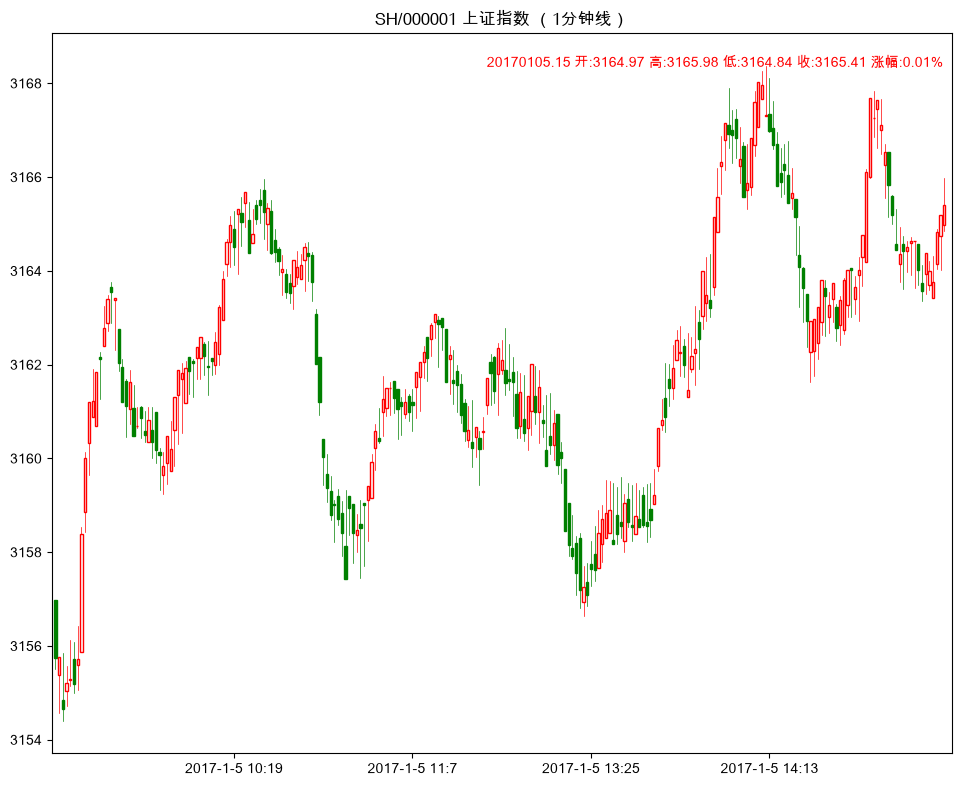

In [8]:
# Query the daily data from 2017-01-01 to now
k = s.get_kdata(Query(Datetime(201701010000)))

# Query the daily data from 2017-01-01 to 03-31
k = s.get_kdata(Query(Datetime(201701010000), Datetime(201704010000)))

# Query the 1-minute data of 2017-01-05
k = s.get_kdata(Query(Datetime(201701050000), Datetime(201701060000), ktype=Query.MIN))
k.plot()

3.3 Query the adjusted daily line
----------------

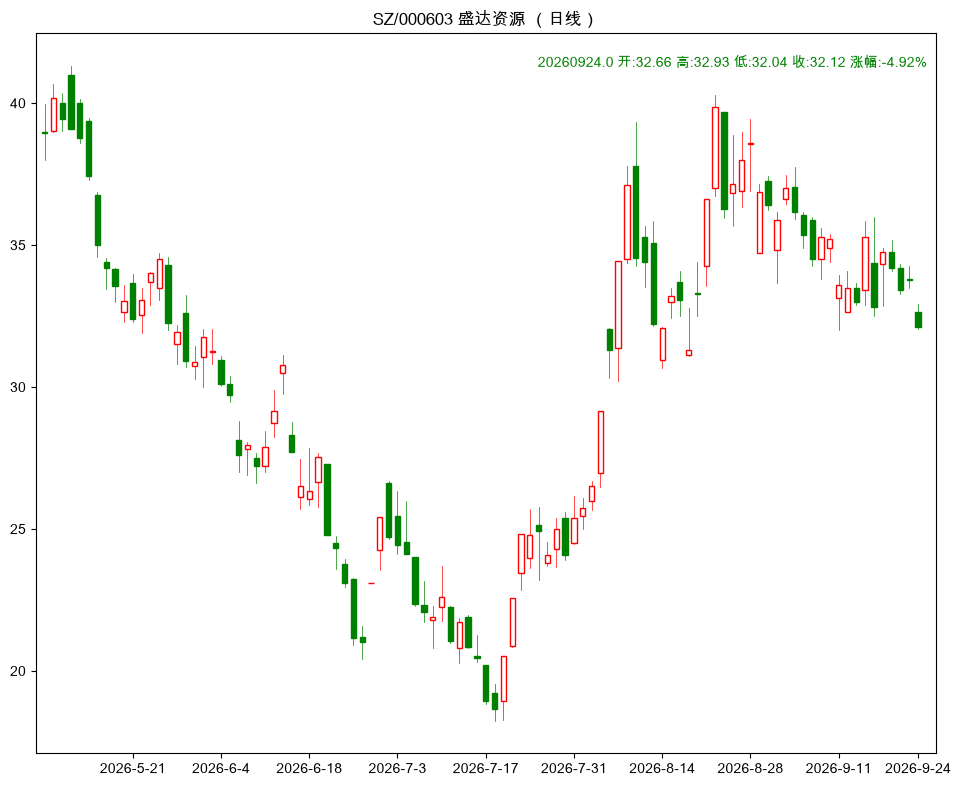

In [9]:
s = sm['sz000603']

# Query the K-line data of the last 100 trading days of the stock, without adjustment
k = s.get_kdata(Query(-100))
k.plot()

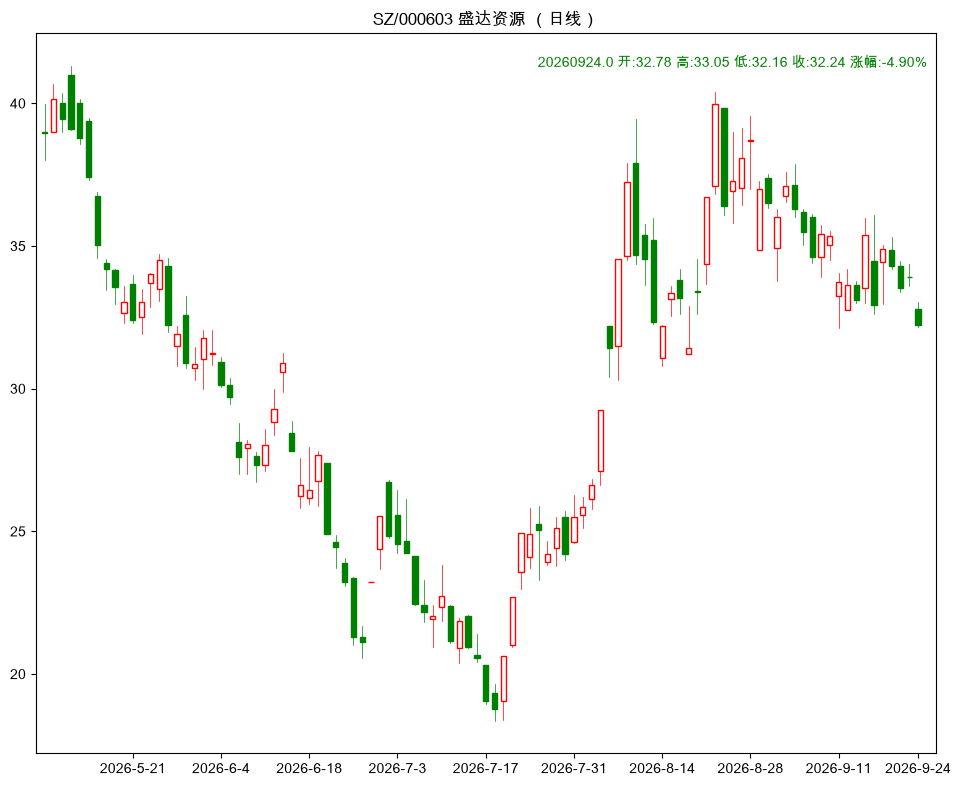

In [10]:
# Query the K-line data of the last 100 trading days of the stock, with backward adjustment
k = s.get_kdata(Query(-100, recover_type=Query.BACKWARD))
k.plot()